### RQ: Do we notice distinct learning patterns among students? 

#### 0. Preprocessing of AI Usage by student (by count of messages)

In [1]:
# Import the tables of the data set as dataframes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "./data" # You many change the directory

# Other main package imports
import seaborn as sns
import scipy as sc

# Scikit-learn package imports
from sklearn import feature_extraction, model_selection
from sklearn.metrics import root_mean_squared_error, mean_squared_error, roc_auc_score

# PyBKT package imports
import random
old_randint = random.randint
random.randint = lambda a, b: old_randint(a, int(b))
from pyBKT.models import Model
random.randint = old_randint



In [2]:
# 1. Map Gymitrainer data to rest of tables 
gymitrainer_df = pd.read_csv(f"{DATA_DIR}/gymitrainer.csv")
gymitrainer_df = gymitrainer_df.drop(columns=['chat_profile'])
#display(gymitrainer_df.head())
mapping_df = pd.read_csv(f"{DATA_DIR}/mapping.csv")
#display(mapping_df.head())

threshold = 0.5
filtered_mapping = mapping_df[mapping_df['confidence'] >= threshold]

# Contains only users where the matching is confident enough and who 
# used the chatbot at all (since they appear in gymitrainer.csv)
# Inner merging guarantees that we only have people who used the chatbot
matched_gymitrainer = pd.merge(
    gymitrainer_df,
    filtered_mapping[['id', 'user_id']],
    on='id',
    how='inner'  
)

In [3]:
tag_replacements = {
    'Mathehilfe': 'Mathe',
    'math_help': 'Mathe',
    'essay_writing': 'Aufsatz',
    'Aufsatzhilfe': 'Aufsatz',
    'Sprachprufung': 'Sprache',
    'text_comprehension': 'Sprache'
}

matched_gymitrainer['tag'] = matched_gymitrainer['tag'].replace(tag_replacements)

def fill_missing_tag(row):
    if pd.isna(row['tag']) or row['tag'] == '':
        content = str(row['content'])
        if content.startswith("['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor") or \
           content.startswith("['Hallo! Mein Name ist Gymitrainer, und ich bin dein Mathe-Guru"):
            return 'Mathe'
        elif content.startswith("['Hey! Ich bin Gymitrainer, dein Experte für Gymi-Prüfungsaufsätze"):
            return 'Aufsatz'
        else:
            return row['tag']
    else:
        return row['tag']

matched_gymitrainer['tag'] = matched_gymitrainer.apply(fill_missing_tag, axis=1)

matched_gymitrainer = matched_gymitrainer.sort_values(by='user_id')
display(matched_gymitrainer.head())   

,Unnamed: 0,id,tag,message_count,startTime,endTime,content,user_id
1630,4454,321dae4e-6d92-40be-b780-232cecf3b586,NaN,1,1730219336,1730219336,['wie soll ich das rechnen'],4
1629,4453,74677c94-340b-4017-9cba-5d38cd1bf581,Aufsatz,3,1730219315,1730220391,"[""Hey! Ich bin Gymitrainer, dein Experte für G...",4
305,772,109cbf59-7ca4-49d7-9879-40d79e666557,Aufsatz,2,1738769310,1738769622,"[""Hey! Ich bin Gymitrainer, dein Experte für G...",6
313,803,bf6c477d-578b-4234-9126-636c64fc09a4,Mathe,3,1738678028,1738681716,"['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor...",6
526,1443,6923b14e-55b3-4aee-8d9c-fd5305295cb2,Mathe,1,1736181505,1736184444,"['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor...",6


In [4]:
# 2. Remove potential teachers from the dataset as a safety 
# (we only want to study learning on students)
teachers = pd.read_csv(f"{DATA_DIR}/teachers.csv")
teacher_ids = teachers['user_id'].unique()
matched_gymitrainer = matched_gymitrainer[~matched_gymitrainer['user_id'].isin(teacher_ids)].copy()

# 3. Clean and prepare the datasets by subjects 
math_results = pd.read_csv(f"{DATA_DIR}/math_results.csv")
math_questions_clean = pd.read_csv(f"{DATA_DIR}/math_questions_clean.csv")
math_results['question'] = math_results['question'].astype(str)
math_questions_clean['question_id'] = math_questions_clean['question_id'].astype(str)
math_results_clean = math_results[
    math_results['question'].isin(math_questions_clean['question_id'])
] 
math_results_clean = math_results_clean.merge(
    math_questions_clean[['question_id', 'skill_id']],
    left_on='question',
    right_on='question_id',
    how='left'
)
math_results_clean = math_results_clean.drop(columns=['question_id'])
math_results_clean['timestamp'] = math_results_clean['time'].astype(int)
math_results_clean['correct'] = math_results_clean['correct'].astype(int)
math_results_clean['hint_used'] = (math_results_clean['hint_count'] > 0).astype(int)

math_data = math_results_clean[['user_id', 'skill_id', 'correct', 'timestamp', 'hint_used']]



In [5]:
# 4. Define AI usage for each user, by subject (a heavy AI user in Essays might not be a heavy AI 
# user in Math, and the criteria shall not be the same as users send many more messages on average
# to Gymitrainer for Math than for other subjects)
subject_tags = ['Mathe', 'Aufsatz', 'Sprache']

ai_usage_per_subject = matched_gymitrainer[matched_gymitrainer['tag'].isin(subject_tags)].groupby(['user_id', 'tag']).size().unstack(fill_value=0)

for subject in subject_tags:
    if subject not in ai_usage_per_subject.columns:
        ai_usage_per_subject[subject] = 0

print("# of Messages for each User, by Subject", ai_usage_per_subject.head())

def compute_threshold(series, percentile=75):
    non_zero = series[series > 0]
    return np.percentile(non_zero, percentile) if len(non_zero) > 0 else 0

def categorize_usage(count, threshold):
    if count == 0:
        return 'non_ai_user'
    elif count <= threshold:
        return 'light_ai_user'
    else:
        return 'heavy_ai_user'

cutoff_percentile = 75

for subject in subject_tags:
    threshold = compute_threshold(ai_usage_per_subject[subject], percentile=cutoff_percentile)
    ai_usage_per_subject[f'{subject}_ai_usage_category'] = ai_usage_per_subject[subject].apply(
        lambda x: categorize_usage(x, threshold)
    )

print("# of Messages for each User, by Subject", ai_usage_per_subject[[f'{s}_ai_usage_category' for s in subject_tags]].head())

# of Messages for each User, by Subject tag      Aufsatz  Mathe  Sprache
user_id                         
4              1      0        0
6              2      7        0
7              0      2        0
9              0      4        0
11             0      3        0
# of Messages for each User, by Subject tag     Mathe_ai_usage_category Aufsatz_ai_usage_category  \
user_id                                                     
4                   non_ai_user             light_ai_user   
6                 heavy_ai_user             light_ai_user   
7                 light_ai_user               non_ai_user   
9                 light_ai_user               non_ai_user   
11                light_ai_user               non_ai_user   

tag     Sprache_ai_usage_category  
user_id                            
4                     non_ai_user  
6                     non_ai_user  
7                     non_ai_user  
9                     non_ai_user  
11                    non_ai_user  


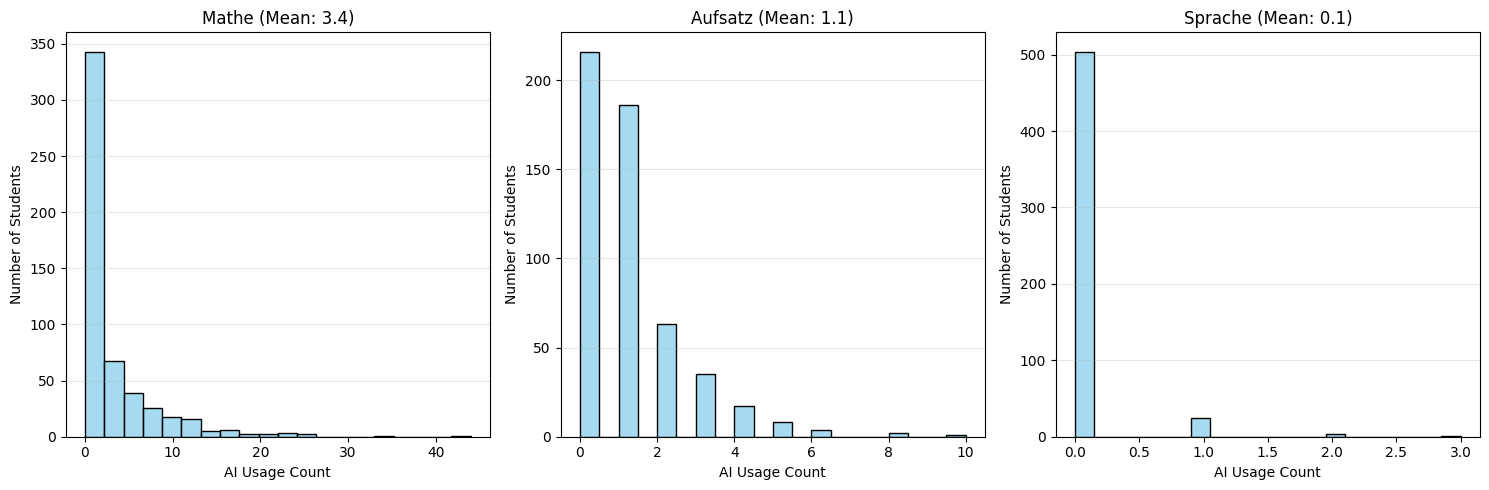

In [6]:
plt.figure(figsize=(15, 5))
for i, subject in enumerate(subject_tags, 1):
    toplot = ai_usage_per_subject[subject]
    if(subject == "Mathe"):
        toplot = ai_usage_per_subject[subject].nsmallest(len(ai_usage_per_subject[subject]) -1 ) #disregard outlier in math
    plt.subplot(1, 3, i)
    sns.histplot(toplot, bins=20, kde=False, color='skyblue')
    plt.title(f'{subject} (Mean: {ai_usage_per_subject[subject].mean():.1f})')
    plt.xlabel('AI Usage Count')
    plt.ylabel('Number of Students')
    plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# 5. Create dataframes that contain info on a user's AI usage
math_data_with_ai = math_data.merge(
    ai_usage_per_subject[['Mathe', 'Mathe_ai_usage_category']], 
    on='user_id', 
    how='left'
)

math_data_with_ai['Mathe'] = math_data_with_ai['Mathe'].fillna(0)
math_data_with_ai['Mathe_ai_usage_category'] = math_data_with_ai['Mathe_ai_usage_category'].fillna('non_ai_user')

math_data_categorical = math_data_with_ai.sort_values(
    by=['user_id', 'timestamp'],
    ascending=[True, True]
).reset_index(drop=True)

In [8]:
# 6. Add order_id column that orders a user-id's submissions by skill and time
math_data_categorical['order_id'] = math_data_categorical.groupby('user_id').cumcount() + 1

# 7. Extra columns added to use for AFM/PFA
def preprocess_data(data):
    data = data.copy()  # Avoid modifying a slice of the original DataFrame
    data.loc[:, 'aux'] = 1
    data.loc[:, 'prev_attempts'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['aux'].cumsum() - 1

    # Number of correct and incorrect attempts before current attempt
    data.loc[:, 'correct_aux'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['correct'].cumsum()
    data.loc[:, 'before_correct_num'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['correct_aux'].shift(periods=1, fill_value=0)
    data.loc[:, 'before_wrong_num'] = data['prev_attempts'] - data['before_correct_num']
    return data

math_data_categorical = preprocess_data(math_data_categorical)

# 7. Visualizations

print("Math data example:")
display(math_data_categorical.head(10))

# 8. Datasets cut by AI Usage for training

df_non_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'non_ai_user'].drop(columns='Mathe_ai_usage_category')
df_light_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'light_ai_user'].drop(columns='Mathe_ai_usage_category')
df_heavy_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'heavy_ai_user'].drop(columns='Mathe_ai_usage_category')

display(df_non_ai_math.head(10))

Math data example:


,user_id,skill_id,correct,timestamp,hint_used,Mathe,Mathe_ai_usage_category,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,non_ai_user,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,non_ai_user,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,10,1,7,4,4,3


,user_id,skill_id,correct,timestamp,hint_used,Mathe,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,10,1,7,4,4,3


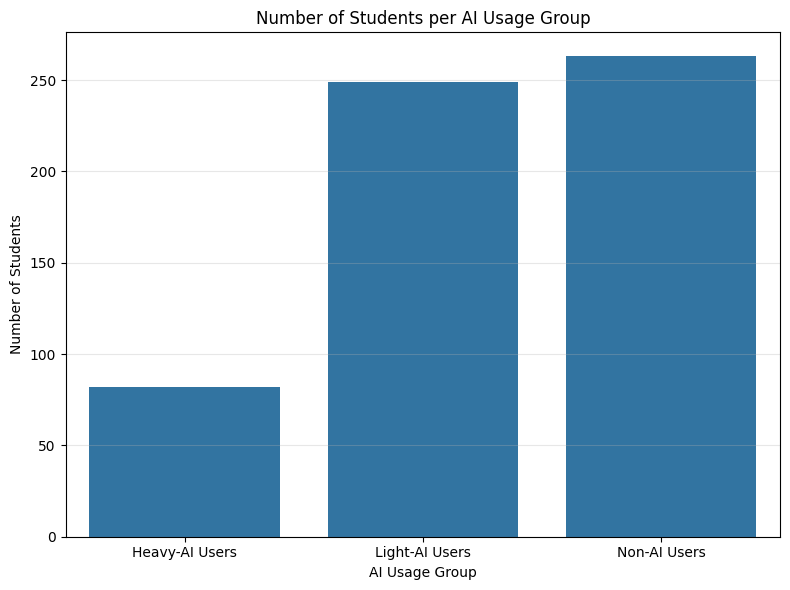

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count unique users in each AI usage category
user_counts = math_data_categorical.groupby('Mathe_ai_usage_category')['user_id'].nunique()

# Optional: Rename index for nicer labels
user_counts.index = user_counts.index.map({
    'non_ai_user': 'Non-AI Users',
    'light_ai_user': 'Light-AI Users',
    'heavy_ai_user': 'Heavy-AI Users'
})

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=user_counts.index, y=user_counts.values)
plt.title('Number of Students per AI Usage Group')
plt.xlabel('AI Usage Group')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()


In [10]:
# Load activity data
activity = pd.read_csv(f"{DATA_DIR}/activity.csv")

# 1.1: Student-level aggregation
columns_to_drop = ['Mathe', 'skill_id', 'order_id', 'aux', 'prev_attempts', 'correct_aux', 'before_correct_num', 'before_wrong_num']
math_cleaned = math_data_categorical.drop(columns=columns_to_drop, errors='ignore')

math_summary = math_cleaned.groupby('user_id').agg({
    'correct': ['mean', 'std', 'count'],
    'hint_used': 'mean',
    'Mathe_ai_usage_category': 'first'
})

# Rename columns
math_summary.columns = ['avg_accuracy', 'std_accuracy', 'total_questions', 'hint_usage_rate', 'ai_usage_category']
math_summary = math_summary.reset_index()

# Add activity counts
activity_counts = activity.groupby('user_id').size().rename('activity_count')
math_data_clustering_student = math_summary.merge(activity_counts, on='user_id', how='left').fillna(0)
#display(math_data_clustering_student['ai_usage_category'].head(10))



# 1.2: Student-Skill-level aggregation
columns_to_drop = ['Mathe', 'order_id', 'aux', 'prev_attempts', 'correct_aux', 'before_correct_num', 'before_wrong_num']
math_cleaned_skill = math_data_categorical.drop(columns=columns_to_drop, errors='ignore')

math_skill_summary = math_cleaned_skill.groupby(['user_id', 'skill_id']).agg({
    'correct': ['mean', 'std', 'count'],
    'hint_used': 'mean',
    'Mathe_ai_usage_category': 'first'
})

# Rename columns
math_skill_summary.columns = ['avg_accuracy', 'std_accuracy', 'total_questions', 'hint_usage_rate', 'ai_usage_category']
math_skill_summary = math_skill_summary.reset_index()

# Add activity count (per user only)
activity_counts = activity.groupby('user_id').size().rename('activity_count')
math_data_clustering_studentskill = math_skill_summary.merge(activity_counts, on='user_id', how='left').fillna(0)

# Preview both
#math_data_clustering_student.head(), math_data_clustering_studentskill.head()

print(math_data_clustering_student['ai_usage_category'].value_counts())

ai_usage_category
non_ai_user      263
light_ai_user    249
heavy_ai_user     82
Name: count, dtype: int64


In [11]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt

# # 1. Basics
# df = math_data_clustering_student.copy()
# # .1 
# user_ids = df['user_id'] 
# X = df.drop(columns=['user_id', 'hint_usage_rate', 'total_questions'], errors='ignore')
# # .2
# numeric_columns = X.select_dtypes(include=[np.number]).columns
# X = X[numeric_columns].dropna()
# print(X)

# # 2. Feature Scaling
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # 3. Elbow and Silhouette Score Computation for k=2…10
# K_range    = range(2, 11)
# inertias   = []
# sil_scores = []

# for k in K_range:
#     km = KMeans(n_clusters=k, random_state=42)
#     labels = km.fit_predict(X_scaled)
#     inertias.append(km.inertia_)
#     sil_scores.append(silhouette_score(X_scaled, labels))

# # 4. Plotting
# plt.figure(figsize=(12,4))

# plt.subplot(1,2,1)
# plt.plot(K_range, inertias, marker='o')
# plt.title("Elbow: Inertia vs k")
# plt.xlabel("k")
# plt.ylabel("Inertia")
# plt.grid(True)

# plt.subplot(1,2,2)
# plt.plot(K_range, sil_scores, marker='o', color='C1')
# plt.title("Silhouette Score vs k")
# plt.xlabel("k")
# plt.ylabel("Silhouette Score")
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # 5. PCA for 2D projection
# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X_scaled)
# print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_)

# #####
# # from sklearn.metrics import silhouette_samples
# # labels = kmeans.labels_
# # sil_vals = silhouette_samples(X_pc, labels)
# # fig, ax = plt.subplots(figsize=(6,4))

# # y_lower = 10
# # for i in np.unique(labels):
# #     ith_sil = np.sort(sil_vals[labels == i])
# #     size_i = ith_sil.shape[0]
# #     y_upper = y_lower + size_i
# #     ax.fill_betweenx(np.arange(y_lower, y_upper),
# #                      0, ith_sil, alpha=0.7)
# #     ax.text(-0.02, y_lower + 0.5 * size_i, f"Cluster {i}")
# #     y_lower = y_upper + 10

# # ax.set_xlabel("Silhouette Coefficient")
# # ax.set_ylabel("Cluster")
# # plt.show()
# ######

# # 6. Choose your final k (e.g. where elbow & silhouette suggest optimal)
# optimal_k = 2
# kmeans = KMeans(n_clusters=optimal_k, random_state=42)
# clusters = kmeans.fit_predict(X_scaled)

# # 7. Build a results DataFrame
# results = pd.DataFrame({
#     'user_id': user_ids,
#     'PC1':      X_pca[:,0],
#     'PC2':      X_pca[:,1],
#     'cluster':  clusters
# })

# # 8. Scatter‐plot PCA+clusters
# plt.figure(figsize=(6,5))
# sns.scatterplot(
#     data=results, x='PC1', y='PC2',
#     hue='cluster', palette='tab10', s=60
# )
# plt.title(f"PCA Plot: k={optimal_k}")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.legend(title="Cluster")
# plt.grid(True)
# plt.show()

# # 9. Heatmap of cluster centers in original feature space
# centers = scaler.inverse_transform(kmeans.cluster_centers_)
# centers_df = pd.DataFrame(centers, columns=X.columns).T
# plt.figure(figsize=(6,8))
# sns.heatmap(centers_df, annot=True, cmap='vlag')
# plt.title("Cluster Centers (original feature values)")
# plt.ylabel("Feature")
# plt.xlabel("Cluster")
# plt.show()

# # 10. Print average feature values per cluster
# df_with_cluster = df.copy()
# df_with_cluster['cluster'] = clusters
# print(df_with_cluster.groupby('cluster').mean(numeric_only=True))

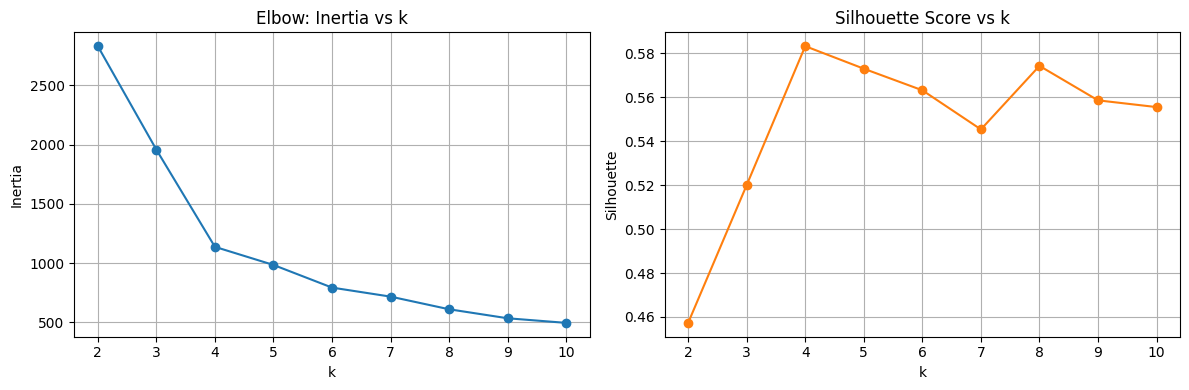

Explained variance ratio (PC1, PC2): [0.52821201 0.20980078]
Optimal k by silhouette: 4


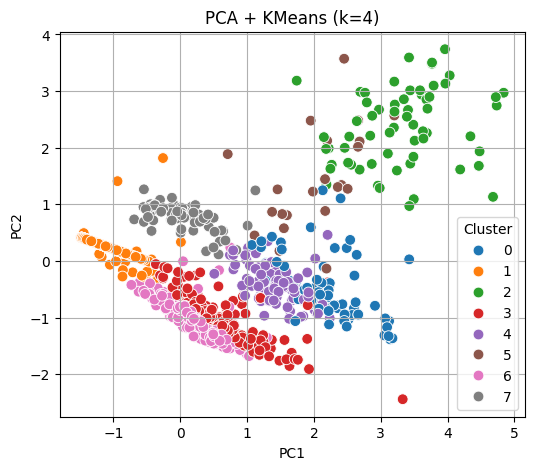

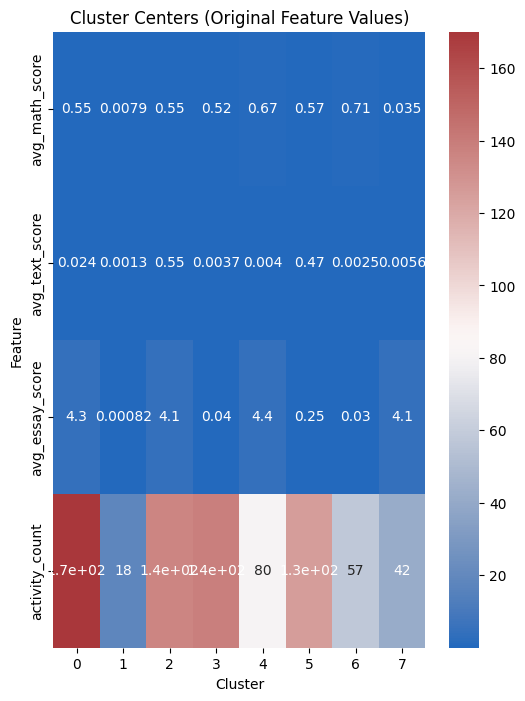

Cluster profiles (mean feature values):
         avg_math_score  avg_text_score  avg_essay_score  activity_count
cluster                                                                 
0               0.54607         0.02397          4.34566       170.05333
1               0.00794         0.00127          0.00082        18.24000
2               0.55281         0.54620          4.09395       135.56452
3               0.51729         0.00368          0.04021       138.21374
4               0.66891         0.00401          4.39466        80.45918
5               0.57389         0.46605          0.25216       125.09091
6               0.71400         0.00252          0.02955        57.27895
7               0.03471         0.00565          4.11791        41.57377


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Load your tables
students      = pd.read_csv(f"{DATA_DIR}/students.csv")
activity      = pd.read_csv(f"{DATA_DIR}/activity.csv")
math_results  = pd.read_csv(f"{DATA_DIR}/math_results.csv")
text_results  = pd.read_csv(f"{DATA_DIR}/text_results.csv")
essay_results = pd.read_csv(f"{DATA_DIR}/essay_results.csv")

# 2. Aggregate per‐student features (rename if your value column is not "score")
math_avg  = math_results.groupby("user_id")["points"].mean().rename("avg_math_score")
text_results["text_score_ratio"] = text_results["points"] / text_results["max_points"]
text_avg  = text_results.groupby("user_id")["text_score_ratio"].mean().rename("avg_text_score")
grading_columns = [
    "content-on_topic", "content-plausible", "content-convincing_ideas", "content-scope",
    "structure-coherence", "structure-outline", "structure-repetition", "structure-text_pattern",
    "language-clarity", "language-spelling", "language-puncutation",
    "language-word_choice", "language_sentence-structure", "language_style"
]
essay_results['essay_score'] = essay_results[grading_columns].mean(axis=1)

essay_avg = essay_results.groupby('user_id')['essay_score'].mean().rename('avg_essay_score')
act_count = activity.groupby("user_id").size().rename("activity_count")

# 3. Build the feature DataFrame
features = (
    pd.concat([math_avg, text_avg, essay_avg, act_count], axis=1)
      .fillna(0)
      .reset_index()
)

# 4. Prepare matrix and scale
X = features.drop(columns=["user_id"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Elbow & Silhouette sweep for k=2…10
Ks, inertias, sil_scores = range(2,11), [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

# 6. Plot diagnostics
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(Ks, inertias, "o-")
plt.title("Elbow: Inertia vs k")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(Ks, sil_scores, "o-", color="C1")
plt.title("Silhouette Score vs k")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.grid(True)
plt.tight_layout()
plt.show()

# 7. PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

# 8. Pick the k with max silhouette
optimal_k = Ks[sil_scores.index(max(sil_scores))]
print("Optimal k by silhouette:", optimal_k)

# 9. Fit final K-Means
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 10. Assemble results
results = features.copy()
results["cluster"] = clusters
results["PC1"] = X_pca[:,0]
results["PC2"] = X_pca[:,1]

# 11. PCA scatter with cluster coloring
plt.figure(figsize=(6,5))
sns.scatterplot(data=results, x="PC1", y="PC2", hue="cluster", palette="tab10", s=60)
plt.title(f"PCA + KMeans (k={optimal_k})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster"); plt.grid(True)
plt.show()

# 12. Heatmap of cluster centers in original features
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=X.columns).T
plt.figure(figsize=(6,8))
sns.heatmap(centers_df, annot=True, cmap="vlag")
plt.title("Cluster Centers (Original Feature Values)")
plt.ylabel("Feature"); plt.xlabel("Cluster")
plt.show()

# 13. Print cluster profiles
print("Cluster profiles (mean feature values):")
print(results.groupby("cluster")[["avg_math_score","avg_text_score","avg_essay_score","activity_count"]].mean())

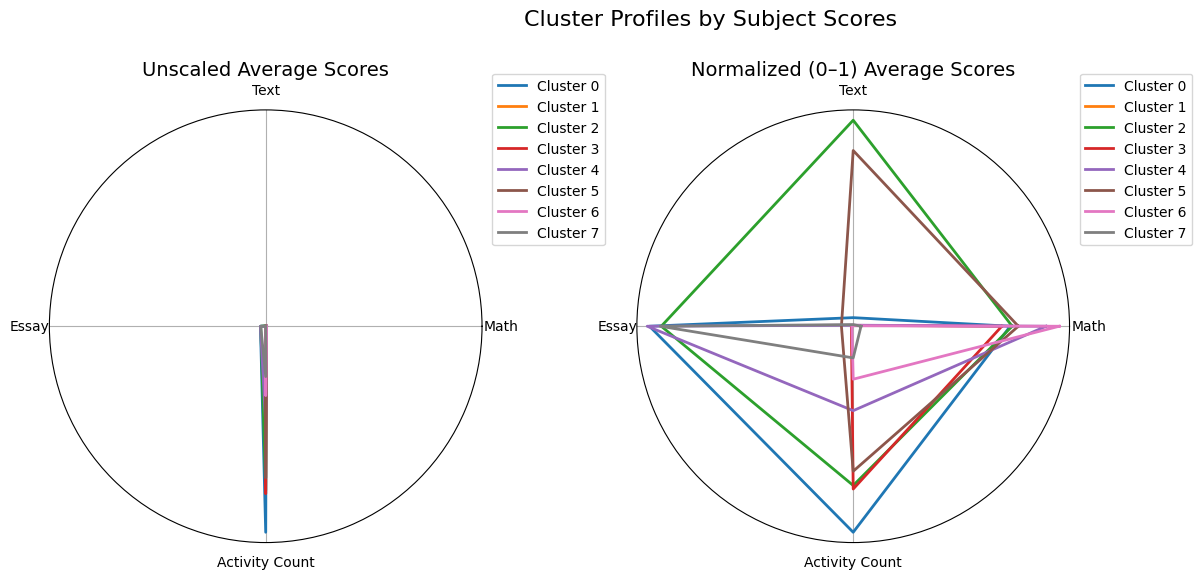

In [16]:
from sklearn.preprocessing import MinMaxScaler

def plot_cluster_subject_profiles(df_clustered, subject_columns, cluster_col="cluster"):
    """
    Creates side-by-side radar plots of cluster-average subject scores,
    both unscaled and normalized.
    """
    # Create readable labels
    def prettify(label):
        return label.replace("avg_", "").replace("_score", "").replace("_", " ").title()
    labels = [prettify(col) for col in subject_columns]
    
    # Compute cluster mean profiles
    profiles = df_clustered.groupby(cluster_col)[subject_columns].mean()
    
    # Normalize for the second plot
    scaler = MinMaxScaler()
    profiles_scaled = pd.DataFrame(
        scaler.fit_transform(profiles),
        columns=profiles.columns,
        index=profiles.index
    )
    
    # Radar setup
    num_vars = len(subject_columns)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    colors = plt.cm.tab10.colors
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))
    
    # Unscaled plot
    ax = axes[0]
    for idx, (cluster, row) in enumerate(profiles.iterrows()):
        vals = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, vals, color=colors[idx], linewidth=2, label=f"Cluster {cluster}")
    ax.set_title("Unscaled Average Scores", fontsize=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    # Normalized plot
    ax = axes[1]
    for idx, (cluster, row) in enumerate(profiles_scaled.iterrows()):
        vals = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, vals, color=colors[idx], linewidth=2, label=f"Cluster {cluster}")
    ax.set_title("Normalized (0–1) Average Scores", fontsize=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.suptitle("Cluster Profiles by Subject Scores", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


plot_cluster_subject_profiles(results, ["avg_math_score","avg_text_score","avg_essay_score","activity_count"])

#### 2. Hint-usage for Math Assignments by Cluster 

In [17]:
# 1. Per‐user average hint usage
user_hint_avg = math_results.groupby('user_id')['hint_count']     \
                       .mean()                                 \
                       .rename('avg_hint_usage')

# 2. Merge with your clustering results
#    (results must have columns ['user_id','cluster'])
results_with_hints = results.merge(user_hint_avg, on='user_id', how='left') \
                            .fillna({'avg_hint_usage': 0})

# 3. Compute the mean by cluster
cluster_hint_profile = (
  results_with_hints
    .groupby('cluster')['avg_hint_usage']
    .mean()
    .reset_index 
)

print('Average hint usage by students, by cluster:', cluster_hint_profile, sep="\n")

Average hint usage by students, by cluster:
<bound method Series.reset_index of cluster
0   0.04806
1   0.00177
2   0.05604
3   0.05760
4   0.03575
5   0.05278
6   0.05229
7   0.01000
Name: avg_hint_usage, dtype: float64>


#### 3. Classroom Repartition by Cluster

In [22]:
# 1. Merge cluster labels with student group IDs
merged = (
    results[['user_id', 'cluster']]
      .merge(students[['user_id', 'group_id']], on='user_id')
)

# 2. Compute total per cluster for percentages
total_per_cluster = merged.groupby('cluster').size().rename('total_students')

# 3. Count per (group_id, cluster)
counts = merged.groupby(['group_id','cluster']).size().unstack(fill_value=0)

# 4. Compute percentages per cluster
percentages = counts.div(total_per_cluster, axis=1) * 100

# 5. Build formatted cells: "count (pct%)"
formatted = counts.astype(str) + " (" + percentages.round(1).astype(str) + "%)"

# 6. Display the pivoted table with group_id as rows, cluster numbers as columns
print(formatted)

cluster            0           1           2           3           4  \
group_id                                                               
94          3 (4.6%)  24 (19.8%)    0 (0.0%)    8 (6.0%)    1 (1.1%)   
95          2 (3.1%)  16 (13.2%)    0 (0.0%)   10 (7.5%)    1 (1.1%)   
96          0 (0.0%)    1 (0.8%)    0 (0.0%)    0 (0.0%)    2 (2.3%)   
97        11 (16.9%)    0 (0.0%)    2 (3.3%)    0 (0.0%)    4 (4.5%)   
99          1 (1.5%)    1 (0.8%)    0 (0.0%)   11 (8.3%)    0 (0.0%)   
101         0 (0.0%)    0 (0.0%)    0 (0.0%)    7 (5.3%)    0 (0.0%)   
103        7 (10.8%)   12 (9.9%)    0 (0.0%)    6 (4.5%)    1 (1.1%)   
104         0 (0.0%)    3 (2.5%)  18 (30.0%)    0 (0.0%)    0 (0.0%)   
105         3 (4.6%)    1 (0.8%)    0 (0.0%)    2 (1.5%)    3 (3.4%)   
106         1 (1.5%)    0 (0.0%)    0 (0.0%)    4 (3.0%)    2 (2.3%)   
107         5 (7.7%)    0 (0.0%)    5 (8.3%)    0 (0.0%)    6 (6.8%)   
108         0 (0.0%)    0 (0.0%)    1 (1.7%)    2 (1.5%)    5 (5

#### 4. AI Usage Repartition by Cluster

In [29]:
# 0. Keep one row per user_id in math_data_categorical to compute merg
math_unique = (
    math_data_categorical
      .drop_duplicates(subset='user_id', keep='first')
)

# 1. Merge cluster labels with student group IDs
merged = (
    results[['user_id', 'cluster']]
      .merge(math_unique[['user_id', 'Mathe_ai_usage_category']], on='user_id')
)

# 2. Compute total per cluster for percentages
total_per_cluster = merged.groupby('cluster').size().rename('total_students')

# 3. Count per (Mathe_ai_usage_category, cluster)
counts = merged.groupby(['Mathe_ai_usage_category','cluster']).size().unstack(fill_value=0)

# 4. Compute percentages per cluster
percentages = counts.div(total_per_cluster, axis=1) * 100

# 5. Build formatted cells: "count (pct%)"
formatted = counts.astype(str) + " (" + percentages.round(1).astype(str) + "%)"

# 6. Display the pivoted table with group_id as rows, cluster numbers as columns
print(formatted)

cluster                           0           1           2           3  \
Mathe_ai_usage_category                                                   
heavy_ai_user            20 (29.0%)    0 (0.0%)  21 (34.4%)  26 (21.0%)   
light_ai_user            32 (46.4%)   3 (13.0%)  36 (59.0%)  59 (47.6%)   
non_ai_user              17 (24.6%)  20 (87.0%)    4 (6.6%)  39 (31.5%)   

cluster                           4           5            6          7  
Mathe_ai_usage_category                                                  
heavy_ai_user              4 (4.1%)   5 (22.7%)     6 (3.2%)   0 (0.0%)  
light_ai_user            37 (37.8%)  11 (50.0%)   70 (37.0%)  1 (12.5%)  
non_ai_user              57 (58.2%)   6 (27.3%)  113 (59.8%)  7 (87.5%)  
